## Agent 2 : Sequential Agent

### Problem Statement
    1.Design Multiple Nodes:
    Create a set of nodes where each node is responsible for processing and updating a specific part of a shared state.

    2.Connect Nodes Sequentially:
    Link these nodes together to form a directed graph where data flows in a defined sequence from one node to the next.

    3.Track State Transformation:
    Execute the graph and observe how the shared state is progressively transformed as it passes through each node in sequence.

In [1]:
import os
import getpass
#os.environ["LANGCHAIN_TRACING_V2"] = "true"
#if not os.environ.get("LANGSMITH_API_KEY"):
#    os.environ["LANGSMITH_API_KEY"] = getpass.getpass()

In [2]:
from typing import TypedDict,List
from langgraph.graph import StateGraph, START,END

/home/labuser/.local/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
class AgentState(TypedDict):
    employee_name:str
    phone_number:int
    final:str

In [4]:
def node_one(state:AgentState)->AgentState:
    """This node greets the employee"""
    state['final'] = f"""Hi {state["employee_name"]}!"""
    return state

def node_two(state:AgentState)->AgentState:
    """This node prints the employee phone number"""
    state['final']= state['final'] + f""" could you please confirm if your phone number is {state['phone_number']}?"""
    return state

In [5]:
graph=StateGraph(AgentState)

graph.add_node('node_one',node_one)
graph.add_node('node_two',node_two)

graph.add_edge('node_one','node_two')


graph.set_entry_point('node_one')
graph.set_finish_point('node_two')

app=graph.compile()

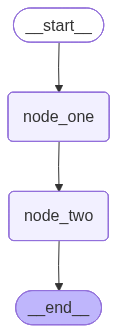

In [6]:
graph.compile()

In [10]:
# from IPython.display import Image, display
# display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
response=app.invoke({'employee_name':'Mr.ROHIT ','phone_number':9803586121})

In [12]:
response['final']

'Hi Mr.ROHIT ! could you please confirm if your phone number is 9803586121?'